# Support Ticket Intelligence System

## Exploratory Data Analysis (EDA)

### Objective

This notebook performs exploratory data analysis on the customer support ticket dataset.

The analysis focuses on:

- Understanding dataset structure
- Identifying missing values
- Checking duplicate records
- Studying ticket categories
- Analyzing priority distribution
- Understanding customer and product patterns
- Analyzing text features

The insights from this notebook will guide:

- NLP preprocessing
- Feature selection
- Model development
- Evaluation strategy

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

In [3]:
DATA_PATH = "../data/raw/customer_support_tickets.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


## Dataset Dimensions

Checking number of:

- Rows = number of tickets
- Columns = available features

In [5]:
rows, columns = df.shape
print(f"Number of Tickets : {rows}")
print(f"Number of Features: {columns}")

Number of Tickets : 8469
Number of Features: 17


## Dataset Information

Checking:

- Column names
- Data types
- Missing values
- Memory usage

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   str    
 2   Customer Email                8469 non-null   str    
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   str    
 5   Product Purchased             8469 non-null   str    
 6   Date of Purchase              8469 non-null   str    
 7   Ticket Type                   8469 non-null   str    
 8   Ticket Subject                8469 non-null   str    
 9   Ticket Description            8469 non-null   str    
 10  Ticket Status                 8469 non-null   str    
 11  Resolution                    2769 non-null   str    
 12  Ticket Priority               8469 non-null   str    
 13  Ticket Channel

In [7]:
for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

1. Ticket ID
2. Customer Name
3. Customer Email
4. Customer Age
5. Customer Gender
6. Product Purchased
7. Date of Purchase
8. Ticket Type
9. Ticket Subject
10. Ticket Description
11. Ticket Status
12. Resolution
13. Ticket Priority
14. Ticket Channel
15. First Response Time
16. Time to Resolution
17. Customer Satisfaction Rating


## Missing Value Analysis

Missing values can affect:

- NLP processing
- Classification models
- Retrieval system

We identify missing columns before preprocessing.

In [8]:
missing = (
    df.isnull()
    .sum()
    .sort_values(
        ascending=False
    )
)


missing

Customer Satisfaction Rating    5700
Resolution                      5700
Time to Resolution              5700
First Response Time             2819
Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Ticket Subject                     0
Ticket Type                        0
Date of Purchase                   0
Product Purchased                  0
Ticket Priority                    0
Ticket Status                      0
Ticket Description                 0
Ticket Channel                     0
dtype: int64

In [10]:
duplicates = df.duplicated().sum()

print(
    "Duplicate Rows:",
    duplicates
)

Duplicate Rows: 0


## Ticket Type Distribution

Ticket type is one of our prediction targets.

We analyze whether classes are balanced.

In [11]:
ticket_types = (
    df["Ticket Type"]
    .value_counts()
)


ticket_types

Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

In [13]:
priority = (
    df["Ticket Priority"]
    .value_counts()
)


priority

Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64

In [14]:
product_count = (
    df["Product Purchased"]
    .value_counts()
    .head(10)
)


product_count

Product Purchased
Canon EOS              240
GoPro Hero             228
Nest Thermostat        225
Philips Hue Lights     221
Amazon Echo            221
LG Smart TV            219
Sony Xperia            217
Roomba Robot Vacuum    216
LG OLED                213
Apple AirPods          213
Name: count, dtype: int64

## Ticket Description Analysis

Understanding text length helps decide:

- Token limits
- Cleaning strategy
- Vectorization parameters

In [16]:
df["description_length"] = (
    df["Ticket Description"]
    .astype(str)
    .apply(len)
)

df["description_length"].describe()

count    8469.000000
mean      289.821939
std        43.593954
min       151.000000
25%       273.000000
50%       298.000000
75%       318.000000
max       397.000000
Name: description_length, dtype: float64

In [19]:
status_count = (
    df["Ticket Status"]
    .value_counts()
)

status_count

Ticket Status
Pending Customer Response    2881
Open                         2819
Closed                       2769
Name: count, dtype: int64

### Most common words

In [17]:
text = " ".join(
    df["Ticket Description"]
    .astype(str)
)


words = re.findall(
    r"\b[a-zA-Z]+\b",
    text.lower()
)


word_frequency = Counter(words)


word_frequency.most_common(20)

[('the', 26454),
 ('i', 22512),
 ('issue', 11531),
 ('to', 10820),
 ('m', 10319),
 ('my', 9597),
 ('please', 8815),
 ('it', 8747),
 ('with', 8328),
 ('an', 7251),
 ('a', 6869),
 ('having', 6430),
 ('assist', 6258),
 ('ve', 6120),
 ('and', 6022),
 ('is', 5671),
 ('you', 4770),
 ('but', 4385),
 ('this', 4359),
 ('on', 3941)]

### Correlation Analysis

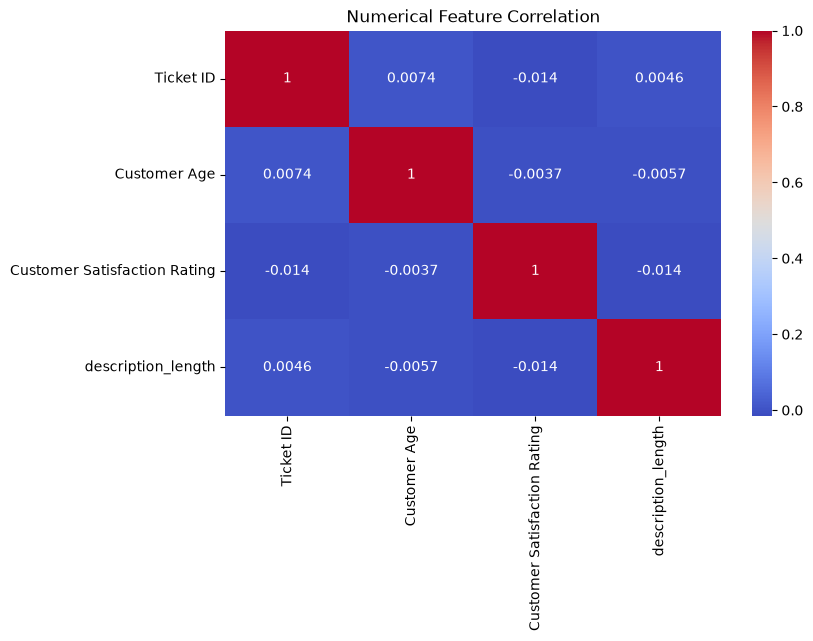

In [18]:
numeric_df = df.select_dtypes(
    include=np.number
)


plt.figure(figsize=(8,5))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Numerical Feature Correlation"
)

plt.show()

In [21]:
df["Customer Satisfaction Rating"].describe()

count    2769.000000
mean        2.991333
std         1.407016
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: Customer Satisfaction Rating, dtype: float64

# EDA Summary

## Dataset Overview

- Total tickets: 8469
- Total features: 17

## Important Features

NLP features:
- Ticket Subject
- Ticket Description
- Resolution

Context features:
- Product Purchased
- Ticket Channel
- Customer Age
- Customer Gender


## Prediction Targets

1. Ticket Type Classification

2. Ticket Priority Classification


## Retrieval System

Resolution will be used to retrieve similar historical solutions.